In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("загрузили")

Matplotlib is building the font cache; this may take a moment.


загрузили


In [5]:
import pandas as pd

df = pd.read_csv("../data/PJME_hourly.csv")

df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  str    
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), str(1)
memory usage: 2.2 MB


In [7]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  145366 non-null  datetime64[us]
 1   PJME_MW   145366 non-null  float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 2.2 MB


In [8]:
df.isnull().sum()

Datetime    0
PJME_MW     0
dtype: int64

Датасет содержит 145 366 наблюдений и 2 признака. После загрузки временная метка была преобразована в формат datetime. Проверка качества данных показала отсутствие пропущенных значений во всех столбцах.

In [9]:
df = df.set_index("Datetime")

df.head()

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0


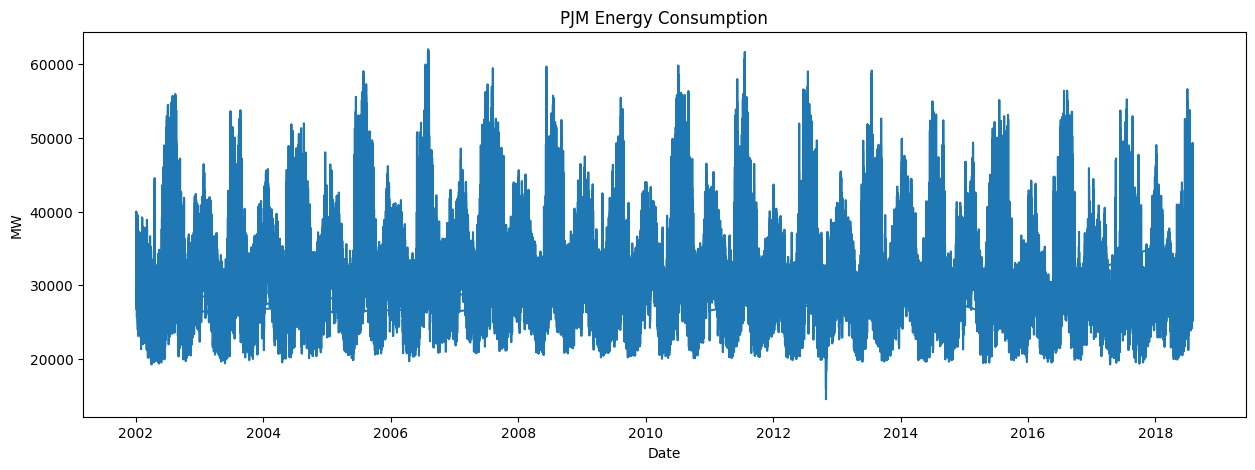

In [10]:
plt.figure(figsize=(15,5))

plt.plot(df.index, df["PJME_MW"])

plt.title("PJM Energy Consumption")
plt.xlabel("Date")
plt.ylabel("MW")

plt.show()

Временной ряд демонстрирует выраженную сезонную структуру. Периоды высокого и низкого энергопотребления регулярно повторяются на протяжении всего периода наблюдений.

Явный долгосрочный возрастающий или убывающий тренд не наблюдается. Средний уровень энергопотребления остается относительно стабильным.

В ряду присутствуют локальные экстремальные значения, которые могут быть связаны с аномальными событиями либо особенностями измерений.

Исходный временной ряд не является стационарным вследствие выраженной сезонной компоненты.

In [11]:
print("Начало ряда:", df.index.min())
print("Конец ряда:", df.index.max())

Начало ряда: 2002-01-01 01:00:00
Конец ряда: 2018-08-03 00:00:00


Исследуемый временной ряд содержит данные о почасовом энергопотреблении региона PJME за период с 01.01.2002 по 03.08.2018. Общая продолжительность наблюдений составляет около 16,5 лет, что позволяет проводить анализ сезонности, трендов и долгосрочных закономерностей.

In [12]:
df.index

DatetimeIndex(['2002-12-31 01:00:00', '2002-12-31 02:00:00',
               '2002-12-31 03:00:00', '2002-12-31 04:00:00',
               '2002-12-31 05:00:00', '2002-12-31 06:00:00',
               '2002-12-31 07:00:00', '2002-12-31 08:00:00',
               '2002-12-31 09:00:00', '2002-12-31 10:00:00',
               ...
               '2018-01-01 15:00:00', '2018-01-01 16:00:00',
               '2018-01-01 17:00:00', '2018-01-01 18:00:00',
               '2018-01-01 19:00:00', '2018-01-01 20:00:00',
               '2018-01-01 21:00:00', '2018-01-01 22:00:00',
               '2018-01-01 23:00:00', '2018-01-02 00:00:00'],
              dtype='datetime64[us]', name='Datetime', length=145366, freq=None)

Структура данных
145 366 наблюдений
1 временной признак (Datetime)
1 целевой признак (PJME_MW)
Качество данных
пропуски отсутствуют;
временная метка успешно преобразована в формат datetime;
временная метка установлена как индекс DataFrame.
Период наблюдений
начало: 01.01.2002
конец: 03.08.2018
Первичный визуальный анализ
присутствует выраженная сезонность;
долгосрочный тренд выражен слабо;
присутствуют локальные выбросы;
ряд визуально не является стационарным.

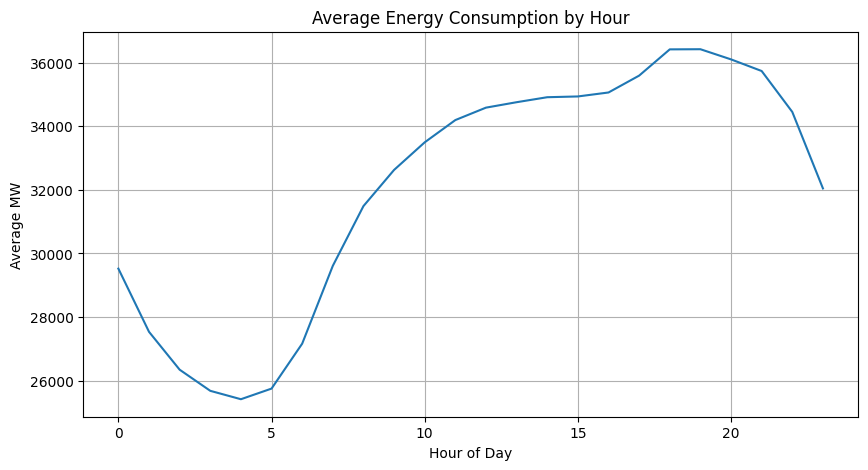

In [13]:
hourly_avg = df.groupby(df.index.hour)["PJME_MW"].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_avg)

plt.title("Average Energy Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average MW")

plt.grid(True)

plt.show()

Анализ среднего энергопотребления по часам суток показал наличие выраженной внутрисуточной сезонности. Минимальное потребление наблюдается в ночные часы (03:00–05:00), а максимальное — в вечерние часы (18:00–20:00). Полученные результаты соответствуют ожидаемому поведению энергосистемы и подтверждают наличие регулярных циклических колебаний во временном ряду.

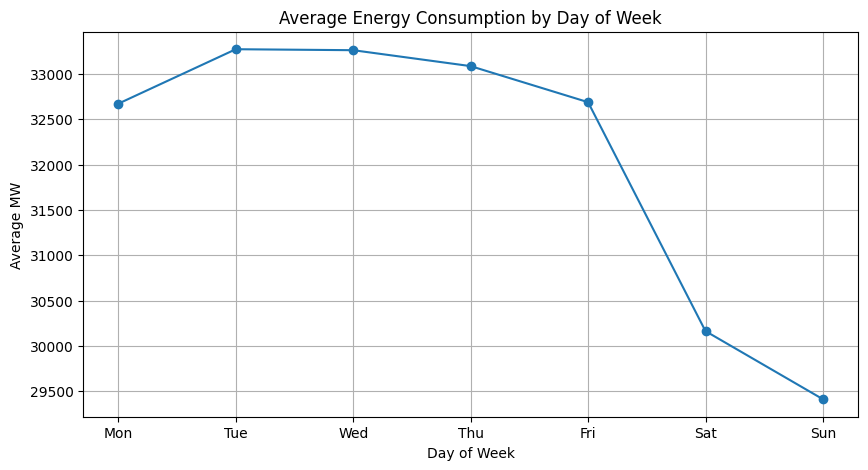

In [14]:
daily_avg = df.groupby(df.index.dayofweek)["PJME_MW"].mean()

plt.figure(figsize=(10,5))
plt.plot(daily_avg, marker="o")

plt.title("Average Energy Consumption by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average MW")

plt.xticks(
    [0,1,2,3,4,5,6],
    ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
)

plt.grid(True)

plt.show()

Анализ среднего энергопотребления по дням недели показал наличие выраженной недельной сезонности. В будние дни уровень потребления остается относительно стабильным, тогда как в выходные наблюдается заметное снижение нагрузки. Минимальные значения зафиксированы в воскресенье. Полученный результат соответствует особенностям промышленного и бытового энергопотребления.

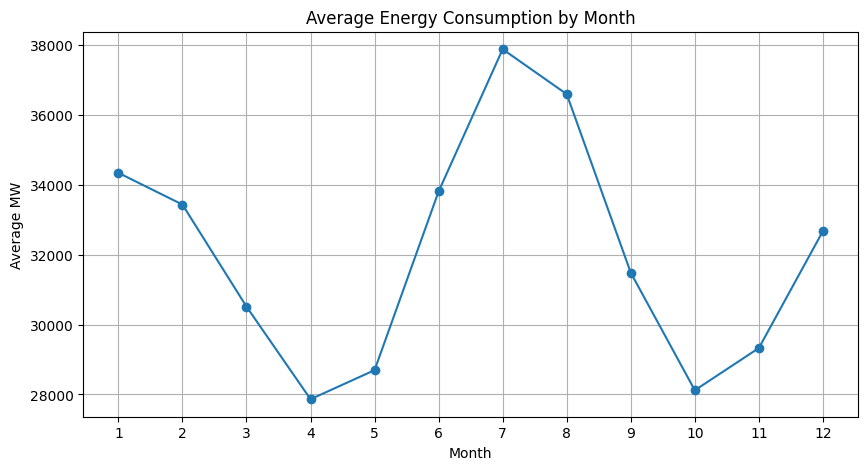

In [15]:
monthly_avg = df.groupby(df.index.month)["PJME_MW"].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_avg, marker="o")

plt.title("Average Energy Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average MW")

plt.xticks(range(1,13))

plt.grid(True)

plt.show()

Анализ среднего энергопотребления по месяцам показал наличие выраженной годовой сезонности. Максимальное потребление наблюдается в летние месяцы (июль–август), что может быть связано с увеличением использования систем кондиционирования. Минимальные значения фиксируются весной и осенью, когда потребность в охлаждении и отоплении снижается.

In [16]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["PJME_MW"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -18.82891272908422
p-value: 2.022124508152674e-30
Critical Values:
1%: -3.430395009088914
5%: -2.861559893380481
10%: -2.5667805885384065


Несмотря на наличие выраженных сезонных колебаний, тест Дики-Фуллера показал статистически значимое отклонение нулевой гипотезы о нестационарности (p-value < 0.05). Таким образом, ряд демонстрирует стационарность относительно среднего уровня, однако содержит выраженные сезонные компоненты различных масштабов.

In [17]:
df_year = df.loc["2017"]

print(df_year.shape)

df_year.head()

(8760, 1)


,PJME_MW
Datetime,
2017-01-01 00:00:00,28171.0
2017-12-31 01:00:00,35242.0
2017-12-31 02:00:00,34410.0
2017-12-31 03:00:00,34150.0
2017-12-31 04:00:00,34220.0


In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose

print("seasonal_decompose loaded")

seasonal_decompose loaded


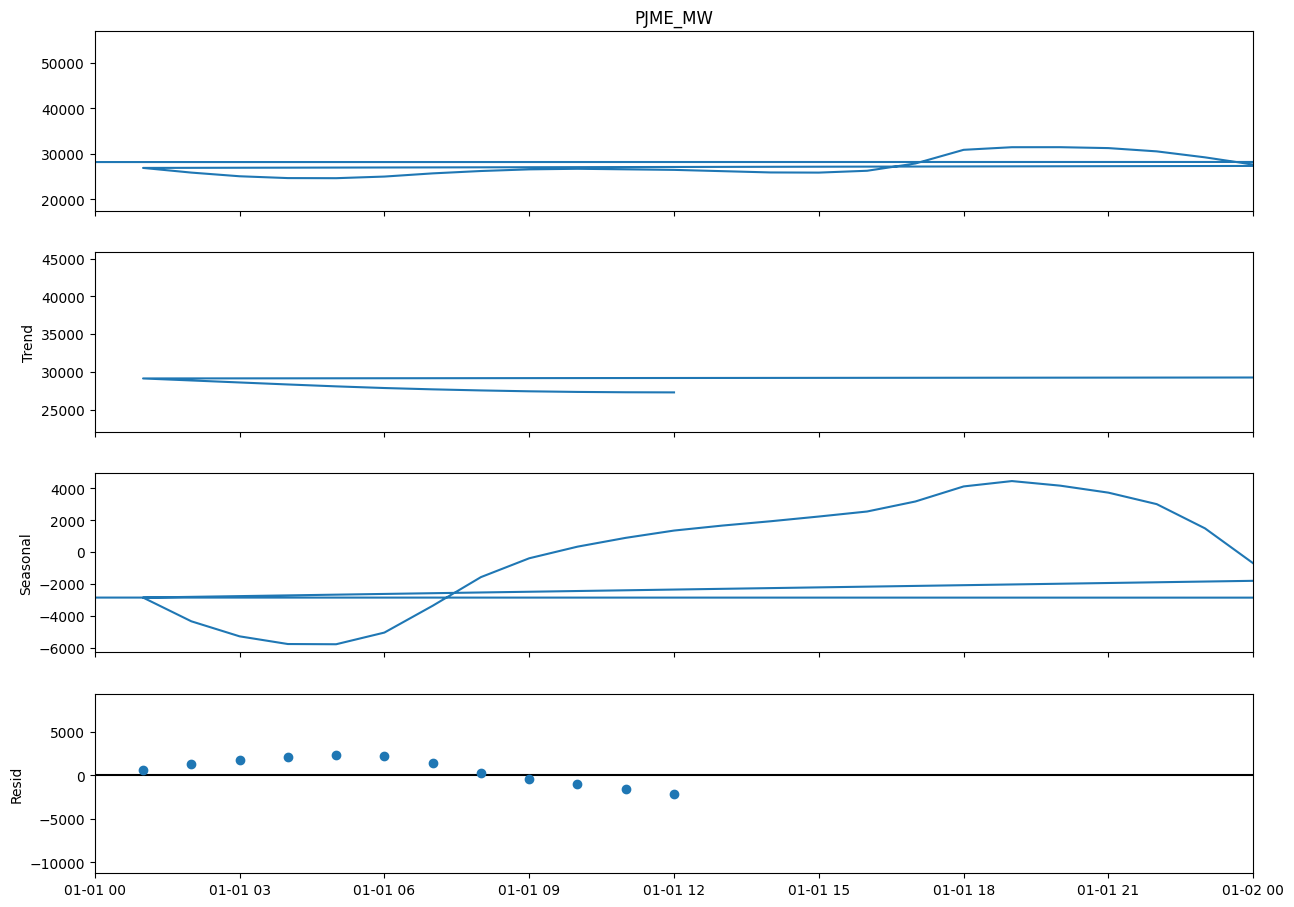

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    df_year["PJME_MW"],
    model="additive",
    period=24
)

fig = decomposition.plot()
fig.set_size_inches(15, 10)

plt.show()

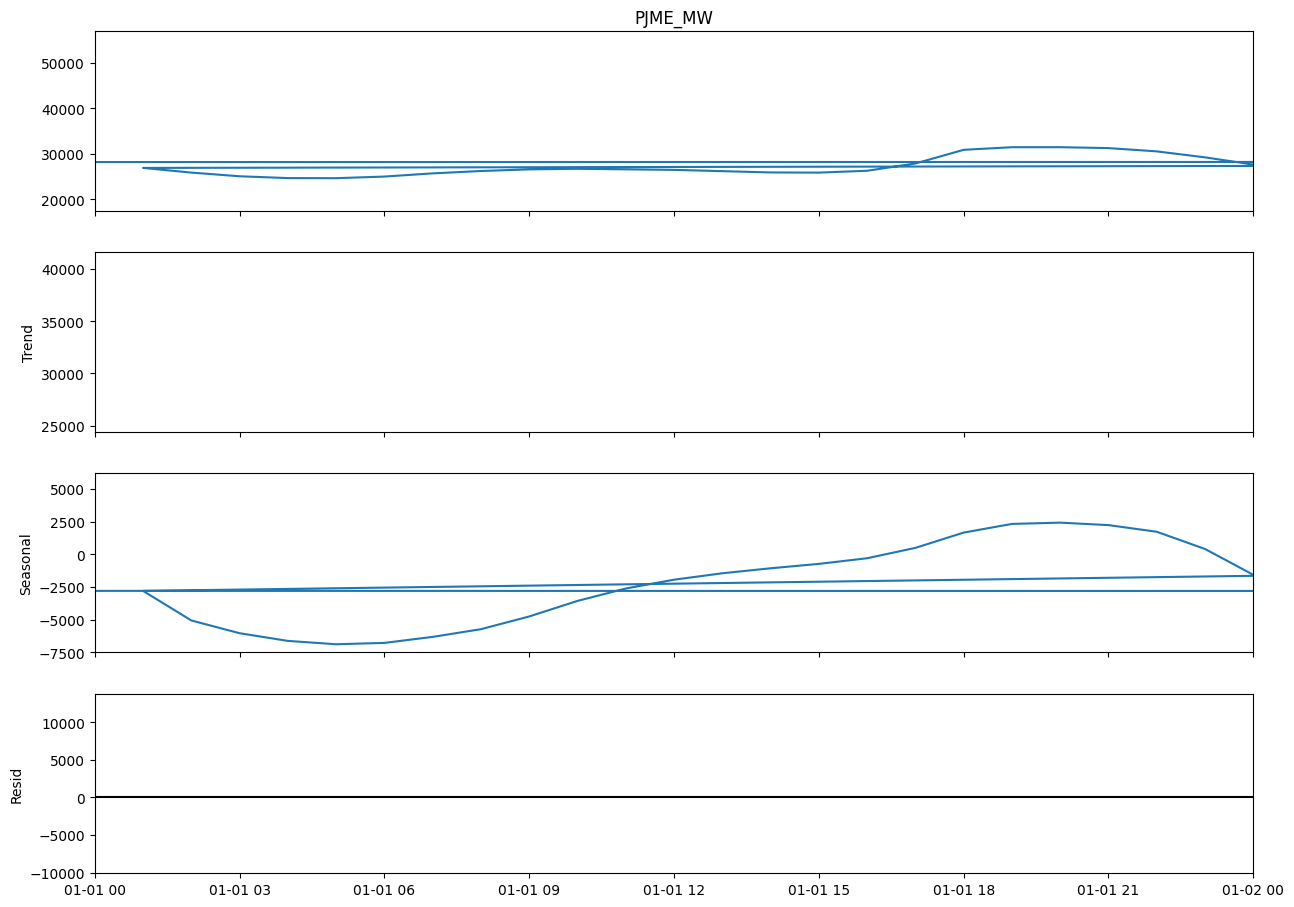

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    df_year["PJME_MW"],
    model="additive",
    period=168
)

fig = decomposition.plot()
fig.set_size_inches(15, 10)

plt.show()

In [21]:
df.to_csv("../data/PJME_prepared.csv")